<h1 style="text-align:center;">Factory Problem</h1>

## Summary

* [**1. Problem Statement**](#0)
* [**2. System Formulation**](#1)
    * [2.1. MDP formulation](#1_1)
    * [2.2. Bellman equation](#1_2)
    * [2.3. Cost function](#1_3)
    * [2.4. Monotonicity of the optimal policy](#1_4)
    * [2.5. Convergence of the algorithm](#1_5)

* [**3. Algorithm**](#2)
* [**4. Abstract**](#3)
    * [4.1. Proof that $J^*(i)$ is increasing](#3_1)
    * [4.2. Proof monotone optimal policy](#3_2)
    * [4.3. Policy Iteration preserves the threshold form](#3_3)

<a id='0'></a>
# 1. Problem statement :

**Problem statement :**

At each time step:

- A producer receives an order with probability $p$
- He receives no order with probability $1 - p$

---

**Decisions :**

At the beginning of each time step, the producer can choose to:

- Process all the waiting orders in one time slot
- Process no order

---

**Costs :**

- Not processing an order costs $c > 0$ per time slot
- Processing all the waiting orders costs $K > 0$

---

**Objective :**

The producer wants to find a processing policy that minimizes the total expected cost, assuming:

- A discount factor $\alpha < 1$
- A maximum number of waiting orders equal to $n$


In [11]:
# Modules 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<a id='1'></a>
# 2. System Formulation :

### 2.1 MDP formulation :

$$
\text{MDP} = (S, A, P, R, \gamma)
$$



<span style="text-decoration: underline; font-size: 1.2em;">
States (S) :
</span>

A state is the number $N$ of waiting order at a discret time $T$ :

$$
s = (N, T)
$$



<span style="text-decoration: underline; font-size: 1.2em;">
Actions (A) :
</span>

The available actions are:

$$
A = \{\text{process all orders}, \text{process no orders}\}
$$



<span style="text-decoration: underline; font-size: 1.2em;">
Transitions (P) :
</span>




Let $s=(N)$ with $N\in\{0,\dots,n\}$ and $a\in A$.


-  Action $a=\text{process no orders}$

For $N<n$:
$$
P\big((N+1,T+1)\mid (N,T),a\big)=p,
\qquad
P\big((N,T+1)\mid (N,T),a\big)=1-p.
$$

For $N=n$:
$$
P\big((n,T+1)\mid (n,T),a\big)=1.
$$



- Action $a=\text{process all orders}$

Processing empties the queue, then an order may arrive during the step:

$$
P\big((1,0)\mid (N,T),a\big)=p,
\qquad
P\big((0,0)\mid (N,T),a\big)=1-p,
\qquad \forall N\in\{0,\dots,n\}.
$$



<span style="text-decoration: underline; font-size: 1.2em;">
Rewards (R) :
</span>

Reward shaping used in the implementation:

- $r_{\text{processing}} = -K$
- $r_{\text{penalty}} = -N \times c$



<span style="text-decoration: underline; font-size: 1.2em;">
Discount Factor α  :
</span>

- $\alpha \in [0,1)$

---

### 2.2 Bellman equation :



Let $J^*(N)$ be the value function when $N$ orders are waiting.

$$
J^*(N) = \min \left\{
\underbrace{
K + \alpha \big[ p \, J^*(1) + (1-p)\, J^*(0) \big]
}_{\text{process all orders}},
\;
\underbrace{
Nc + \alpha \big[ p \, J^*(\min(N+1,n)) + (1-p)\, J^*(N) \big]
}_{\text{process no orders}}
\right\}
$$

---

### 2.3 Cost function (Value function):

$$
J^*(i)
=
\min_{\pi}
\mathbb{E}^{\pi}
\left[
\sum_{t=0}^{\infty} \alpha^{t} \, g(N_t, A_t)
\;\middle|\; N_0 = i
\right]
$$

Where:

- $\pi$ is a **policy** (decision rule), i.e. a strategy that specifies which action to take in each state.
- $g(N_t, A_t)$ is the **one-step cost function**, i.e. the immediate cost incurred when taking action $A_t$ in state $N_t$.


*Proof: $J^* : i \mapsto J^*(i)$ is increasing.* (*[Proof here](##proof1)*)




---

### 2.4 Monotonicity of the optimal policy :

**Proposition.**  
There exists an integer threshold $m^*$ such that the optimal policy satisfies
$$
\pi^*(N)=
\begin{cases}
\text{wait} & N < m^*,\\
\text{process} & N \ge m^*.
\end{cases}
$$

Equivalently,
$$
\text{if processing is optimal at } m,\ \text{then it is optimal for all } N \ge m.
$$


*Proof: Monotonicity of the optimal policy.* (*[Proof here](##proof2)*)

*Proof: Policy Iteration preserves the threshold form.* (*[Proof here](##proof3)*)

---


## 2.5 Convergence of the algorithm

A threshold policy is fully characterized by its threshold $m\in\{0,1,\dots,n+1\}$:
- $m=0$ means “always process”,
- $m=n+1$ means “never process”.

So there are at most $n+2$ distinct threshold policies.

Policy iteration strictly improves the policy unless it is already optimal, so it cannot revisit a previous policy.
Therefore it must terminate after at most:
$$
n+2
$$

---

<a id='2'></a>
# 3. Algorithm :

In [12]:
def policy_evaluation_threshold(p, alpha, c, K, n, m, tol=1e-10, max_iter=200000):
    """
    Evaluate the cost-to-go function J^{pi_m} for a given threshold policy pi_m.

    ------------------------------------------------------------------------
    MDP SETTING
    ------------------------------------------------------------------------
    - State space:      N in {0, ..., n}  (number of waiting orders)
    - Actions:
        * wait   : immediate cost = N * c
                   transition to N with prob (1 - p)
                   transition to min(N+1, n) with prob p
        * process: immediate cost = K
                   transition to 0 with prob (1 - p)
                   transition to 1 with prob p
    - Discount factor:  alpha in [0, 1)

    ------------------------------------------------------------------------
    THRESHOLD POLICY
    ------------------------------------------------------------------------
    pi_m(N) =
        wait    if N < m
        process if N >= m

    This function performs the POLICY EVALUATION step of Policy Iteration,
    restricted to threshold policies.

    ------------------------------------------------------------------------
    NUMERICAL METHOD
    ------------------------------------------------------------------------
    - Iterative fixed-point scheme (Bellman evaluation equation)
    - Gauss–Seidel style updates (in-place, increasing N)
    - Stops when sup-norm difference < tol or max_iter reached
    - No matrix inversion (O(n) memory, scalable for large n)

    ------------------------------------------------------------------------
    RETURNS
    ------------------------------------------------------------------------
    J : ndarray of size (n+1,)
        Approximated cost-to-go function J^{pi_m}(N) for all states N.
    """
    J = np.zeros(n + 1, dtype=float)

    for _ in range(max_iter):
        J_old = J.copy()

        # Gauss-Seidel sweep: update states in increasing order
        for N in range(n + 1):
            if N >= m:
                # process
                J[N] = K + alpha * ((1 - p) * J[0] + p * J[1])
            else:
                # wait
                Np1 = N + 1 if N < n else n
                J[N] = N * c + alpha * ((1 - p) * J[N] + p * J[Np1])

        if np.max(np.abs(J - J_old)) < tol:
            break

    return J


def greedy_threshold_from_value(p, alpha, c, K, n, J):
    """
    Compute the greedy (policy improvement) threshold from a value function J.

    ------------------------------------------------------------------------
    PRINCIPLE
    ------------------------------------------------------------------------
    For each state N, compare the two Q-costs:

        Q_proc(N)  = K + alpha * E[J(next state | process)]
        Q_wait(N)  = N*c + alpha * E[J(next state | wait)]

    - Q_proc is constant in N
    - Q_wait is increasing in N (under monotonic J)

    Therefore the greedy policy has a THRESHOLD STRUCTURE.

    ------------------------------------------------------------------------
    RETURNS
    ------------------------------------------------------------------------
    m' : int
        Smallest N such that processing is optimal.
        The greedy policy is:
            wait    if N < m'
            process if N >= m'
        If never optimal, returns n+1.
    """
    # Q_proc is constant in N
    Q_proc = K + alpha * ((1 - p) * J[0] + p * J[1])

    # Find smallest N such that process is better/equal than wait
    for N in range(n + 1):
        Np1 = N + 1 if N < n else n
        Q_wait = N * c + alpha * ((1 - p) * J[N] + p * J[Np1])
        if Q_proc <= Q_wait:
            return N  # threshold
    return n + 1  # never process


def policy_iteration_threshold(p, alpha, c, K, n, m0=None, tol=1e-10):
    """
    Policy Iteration algorithm restricted to threshold policies.

    ------------------------------------------------------------------------
    ALGORITHM
    ------------------------------------------------------------------------
    Repeat until convergence:

        1) Policy Evaluation:
           Compute J^{pi_m} using policy_evaluation_threshold.

        2) Policy Improvement:
           Extract greedy threshold m' using greedy_threshold_from_value.

    Because the problem admits a threshold optimal policy,
    and threshold policies are preserved by improvement,
    the search space is finite: m in {0, ..., n+1}.

    ------------------------------------------------------------------------
    INPUTS
    ------------------------------------------------------------------------
    p     : arrival probability
    alpha : discount factor
    c     : waiting cost coefficient
    K     : processing fixed cost
    n     : maximum queue size
    m0    : initial threshold (default = n+1 → never process)
    tol   : evaluation convergence tolerance

    ------------------------------------------------------------------------
    RETURNS
    ------------------------------------------------------------------------
    m_star : int
        Optimal threshold.
    J_star : ndarray
        Optimal cost-to-go function associated to m_star.
    iters  : int
        Number of policy improvement iterations.
    """
    if m0 is None:
        m = n + 1  # start with "never process"
    else:
        m = int(m0)

    for it in range(n + 2):
        J = policy_evaluation_threshold(p, alpha, c, K, n, m, tol=tol)
        m_new = greedy_threshold_from_value(p, alpha, c, K, n, J)

        if m_new == m:
            return m, J, it + 1

        m = m_new

    # should never happen due to finite #thresholds
    return m, J, n + 2

In [13]:
# ------------------------------------------------------------
# Application
# ------------------------------------------------------------

c = 1
K = 10
alpha = 0.95
n = 1000

ps = np.arange(0.05, 1.00, 0.05)
m_stars = []
iters_list = []

for p in ps:
    m_star, J_star, iters = policy_iteration_threshold(p, alpha, c, K, n)
    m_stars.append(m_star)
    iters_list.append(iters)

m_stars = np.array(m_stars)
iters_list = np.array(iters_list)

m_stars[:5], iters_list[:5]

(array([1, 2, 2, 2, 3]), array([2, 3, 3, 4, 3]))

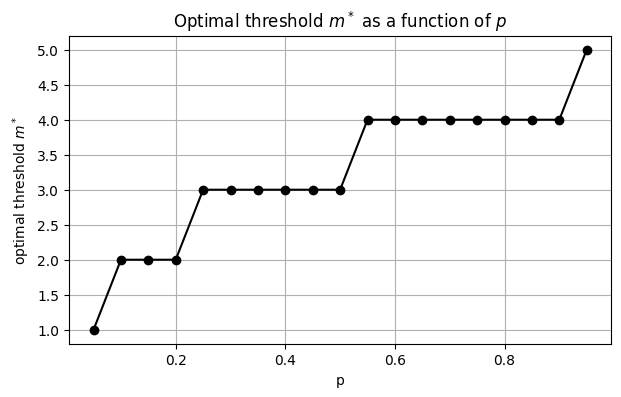

In [17]:
# Plot m* as a function of p
plt.figure(figsize=(7,4))
plt.plot(ps, m_stars, marker="o", color = "black")
plt.xlabel("p")
plt.ylabel("optimal threshold $m^*$")
plt.title("Optimal threshold $m^*$ as a function of $p$")
plt.grid(True)
plt.show()

<a id='3'></a>
# 4. Abstract :

### 4.1 Proof that $J^*(i)$ is increasing (Value Iteration)

<a id="proof1"></a>

Let $N \in \{0,\dots,n\}$.

We define the value iteration sequence $(J_k)_{k\ge 0}$ by:
$$
J_0(N)=0,
$$
and for all $k\ge 0$,
$$
J_{k+1}(N)
=
\min \Big\{
\underbrace{
K + \alpha \big[(1-p)\,J_k(0) + p\,J_k(1)\big]
}_{\text{process all orders}},
\;
\underbrace{
Nc + \alpha \big[(1-p)\,J_k(N) + p\,J_k(\min(N+1,n))\big]
}_{\text{process no orders}}
\Big\}.
$$

We prove by induction that for every $k\ge 0$, the function $N\mapsto J_k(N)$ is increasing, i.e.
$$
J_k(N)\le J_k(N+1), \qquad \forall N\in\{0,\dots,n-1\}.
$$


**Initialisation :**

Since $J_0(N)=0$ for all $N$, we have
$$
J_0(N)=0 \le 0 = J_0(N+1).
$$


**Induction hypothesis :**

Assume that for some $k\ge 0$,
$$
J_k(N)\le J_k(N+1), \qquad \forall N.
$$



**Induction step :**

We show that
$$
J_{k+1}(N)\le J_{k+1}(N+1).
$$

We distinguish two cases.


**If he adapts the processing policy :**

Processing cost does **not depend on $N$**, so

$$
J_{k+1}(N) \le K + \alpha [(1-p) J_k(0) + p J_k(1)]
$$

and

$$
J_{k+1}(N+1) = K + \alpha [(1-p) J_k(0) + p J_k(1)].
$$

Hence both are equal, therefore
$$
J_{k+1}(N) \le J_{k+1}(N+1).
$$


**If he adapts the waiting policy :**

We compare the two waiting costs:

$$
J_{k+1}(N)
\le
Nc + \alpha [(1-p)J_k(N) + pJ_k(N+1)]
$$

and

$$
J_{k+1}(N+1)
=
(N+1)c + \alpha [(1-p)J_k(N+1) + pJ_k(\min(N+2,n))].
$$

Since by hypothesis $J_k(N)\le J_k(N+1)$ and $c>0$, we get

$$
Nc + \alpha [(1-p)J_k(N) + pJ_k(N+1)]
\le
(N+1)c + \alpha [(1-p)J_k(N+1) + pJ_k(\min(N+2,n))].
$$

Thus
$$
J_{k+1}(N) \le J_{k+1}(N+1).
$$

---

### 4.2 Proof monotone optimal policy :

<a id="proof2"></a>

We want to show that:

> If processing is optimal at some state $m$, then it is also optimal at $m+1$.

We compare the two possible decisions at state $N$:
- **process all orders**
- **wait**

---

We already know from Section 4.1 that $J^*(N)$ is increasing.

We distinguish two cases.

---

**Case 1 — Processing is optimal at $m$**

This means:
$$
\text{Cost(process at $m$)} \le \text{Cost(wait at $m$)}.
$$

The processing cost does **not depend on $N$**, it is always:
$$
K + \alpha[(1-p)J^*(0) + pJ^*(1)].
$$

---

**Case 2 — Look at state $m+1$**

- The processing cost is **exactly the same** as at $m$.
- The waiting cost is **larger** than at $m$ because:
  - the term $(m+1)c$ is larger than $mc$,
  - $J^*(m+1) \ge J^*(m)$.

So:
$$
\text{Cost(wait at $m+1$)} \ge \text{Cost(wait at $m$)}.
$$

But we already had:
$$
\text{Cost(process at $m$)} \le \text{Cost(wait at $m$)}.
$$

Therefore:
$$
\text{Cost(process at $m+1$)} \le \text{Cost(wait at $m+1$)}.
$$

So processing is also optimal at $m+1$.


---

### 4.3 Policy Iteration preserves the threshold form

<a id="proof3"></a>

We start with a threshold policy $\pi_m$ defined by:
$$
\pi_m(N)=
\begin{cases}
\text{wait} & \text{if } N<m,\\
\text{proc} & \text{if } N\ge m.
\end{cases}
$$

Let $J^{\pi_m}$ be its value function (solution of the Bellman evaluation equation):
$$
J^{\pi_m}(N)=g(N,\pi_m(N))+\alpha\,\mathbb{E}\Big[J^{\pi_m}(N')\mid N,\pi_m(N)\Big].
$$

### $J^{\pi_m}$ is increasing

Same argument as in Section 2.4 works for a *fixed* policy evaluation operator:
because the one-step cost $g(N,\text{wait})=Nc$ is increasing in $N$ and the transitions under “wait”
move only to $N$ or $N+1$ (monotone transitions), one can show that policy evaluation preserves monotonicity.
Thus:

$$
J^{\pi_m}(N)\ \text{is increasing in }N.
$$

### Improvement step gives a new threshold

In the policy improvement step, we compare:
$$
Q_{\text{proc}}(N;J^{\pi_m})
\quad \text{vs} \quad
Q_{\text{wait}}(N;J^{\pi_m}).
$$

But if $J^{\pi_m}$ is increasing, then $Q_{\text{wait}}(N;J^{\pi_m})$ is increasing in $N$,
while $Q_{\text{proc}}(N;J^{\pi_m})$ is constant in $N$.

Hence the decision set
$$
\{N:\ Q_{\text{proc}}(N;J^{\pi_m})\le Q_{\text{wait}}(N;J^{\pi_m})\}
$$
is of the form $\{m',m'+1,\dots,n\}$ for some $m'$.

So the improved policy is again a threshold policy $\pi_{m'}$.